In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency


In [2]:
df = pd.read_csv("C:\\Users\\bhask\\OneDrive\\Desktop\\Divya\\telco.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [4]:
df['Offer'].value_counts()

Offer
Offer B    824
Offer E    805
Offer D    602
Offer A    520
Offer C    415
Name: count, dtype: int64

In [5]:
df['Churn Category'].value_counts()

Churn Category
Competitor         841
Attitude           314
Dissatisfaction    303
Price              211
Other              200
Name: count, dtype: int64

In [6]:
df['Churn Reason'].value_counts()

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Long distance charges                         64
Service dissatisfaction                       63
Moved                                         46
Extra data charges                            39
Limited range of services                     37
Poor expertise of online support              31
Lack of affordable download/upload speed      30
Lack of self-service on Website               29
Poor expertise of phone support               12
Deceased                                       6
Name: c

In [7]:
print(df.isnull().sum()/len(df)*100)

Customer ID                           0.000000
Gender                                0.000000
Age                                   0.000000
Under 30                              0.000000
Senior Citizen                        0.000000
Married                               0.000000
Dependents                            0.000000
Number of Dependents                  0.000000
Country                               0.000000
State                                 0.000000
City                                  0.000000
Zip Code                              0.000000
Latitude                              0.000000
Longitude                             0.000000
Population                            0.000000
Quarter                               0.000000
Referred a Friend                     0.000000
Number of Referrals                   0.000000
Tenure in Months                      0.000000
Offer                                55.047565
Phone Service                         0.000000
Avg Monthly L

In [8]:
print(df.isnull().sum()[df.isnull().sum()>0])

Offer             3877
Internet Type     1526
Churn Category    5174
Churn Reason      5174
dtype: int64


In [9]:
df['Offer'].mode()

0    Offer B
Name: Offer, dtype: object

In [10]:
df['Churn Category'].mode()

0    Competitor
Name: Churn Category, dtype: object

In [11]:
df['Churn Reason'].mode()

0    Competitor had better devices
Name: Churn Reason, dtype: object

In [12]:
df['Offer'] = df['Offer'].fillna('Offer B')

In [13]:
df['Churn Category'] = df['Churn Category'].fillna('Competitor')

In [14]:
df['Churn Reason'] =df['Churn Reason'].fillna('Competitor had better devices')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [16]:
print(df.isnull().sum()[df.isnull().sum()>0])

Internet Type    1526
dtype: int64


In [17]:
df['Internet Type'].value_counts()

Internet Type
Fiber Optic    3035
DSL            1652
Cable           830
Name: count, dtype: int64

In [18]:
df['Internet Type'].mode()

0    Fiber Optic
Name: Internet Type, dtype: object

In [19]:
df['Internet Type'] = df['Internet Type']. fillna('Fiber Optic')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [21]:
print(df.isnull().sum()[df.isnull().sum()>0])

Series([], dtype: int64)


In [22]:
df.isnull().sum()

Customer ID                          0
Gender                               0
Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
Country                              0
State                                0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Population                           0
Quarter                              0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download  

In [23]:
print(df.isnull().sum()/len(df)*100)

Customer ID                          0.0
Gender                               0.0
Age                                  0.0
Under 30                             0.0
Senior Citizen                       0.0
Married                              0.0
Dependents                           0.0
Number of Dependents                 0.0
Country                              0.0
State                                0.0
City                                 0.0
Zip Code                             0.0
Latitude                             0.0
Longitude                            0.0
Population                           0.0
Quarter                              0.0
Referred a Friend                    0.0
Number of Referrals                  0.0
Tenure in Months                     0.0
Offer                                0.0
Phone Service                        0.0
Avg Monthly Long Distance Charges    0.0
Multiple Lines                       0.0
Internet Service                     0.0
Internet Type   

In [24]:
df1 = df.copy()

In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
num_col = df1.select_dtypes(include='number')

In [28]:
num_col.columns

Index(['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV'],
      dtype='object')

In [29]:
cat_col = df1.select_dtypes(include = 'object')

In [30]:
cat_col.columns

Index(['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Country', 'State', 'City', 'Quarter',
       'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Label',
       'Churn Category', 'Churn Reason'],
      dtype='object')

In [31]:
df1['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [32]:
df1['Churn Label'] = df1['Churn Label'].map({"Yes":1,"No":0})

In [33]:
df1['Churn Label']

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, Length: 7043, dtype: int64

In [34]:
cols = num_col
alpha = 0.05
result = []

for col in cols:
    pearsonr_corr, p_val = pearsonr(df1['Churn Label'],df1[col])
    decision = "Keep Feature" if p_val < alpha else "Reject Feature"

    result.append({
        "Feature":col,
        "pearsonr_corr":pearsonr_corr,
        "p_val":p_val,
        "decision":decision
    })

result = pd.DataFrame(result)
result.sort_values(by='p_val')

,Feature,pearsonr_corr,p_val,decision
16,Satisfaction Score,-0.754649,0.000000e+00,Keep Feature
17,Churn Score,0.660772,0.000000e+00,Keep Feature
7,Tenure in Months,-0.352861,1.329222e-205,Keep Feature
6,Number of Referrals,-0.286540,3.406199e-133,Keep Feature
14,Total Long Distance Charges,-0.223756,1.247019e-80,Keep Feature
15,Total Revenue,-0.223003,4.351662e-80,Keep Feature
1,Number of Dependents,-0.218780,4.420027e-77,Keep Feature
11,Total Charges,-0.198546,1.538899e-63,Keep Feature
10,Monthly Charge,0.193356,2.706646e-60,Keep Feature
18,CLTV,-0.127463,6.679131e-27,Keep Feature


In [35]:
import seaborn as sns

In [36]:
num_col['Churn Label'] = df1['Churn Label']
corr = num_col.corr()['Churn Label'].sort_values(ascending=False)
corr

Churn Label                          1.000000
Churn Score                          0.660772
Monthly Charge                       0.193356
Age                                  0.115760
Population                           0.051649
Avg Monthly GB Download              0.048868
Longitude                            0.024052
Avg Monthly Long Distance Charges    0.008120
Total Extra Data Charges             0.007139
Zip Code                            -0.016289
Total Refunds                       -0.033709
Latitude                            -0.041546
CLTV                                -0.127463
Total Charges                       -0.198546
Number of Dependents                -0.218780
Total Revenue                       -0.223003
Total Long Distance Charges         -0.223756
Number of Referrals                 -0.286540
Tenure in Months                    -0.352861
Satisfaction Score                  -0.754649
Name: Churn Label, dtype: float64

In [37]:
import matplotlib.pyplot as plt

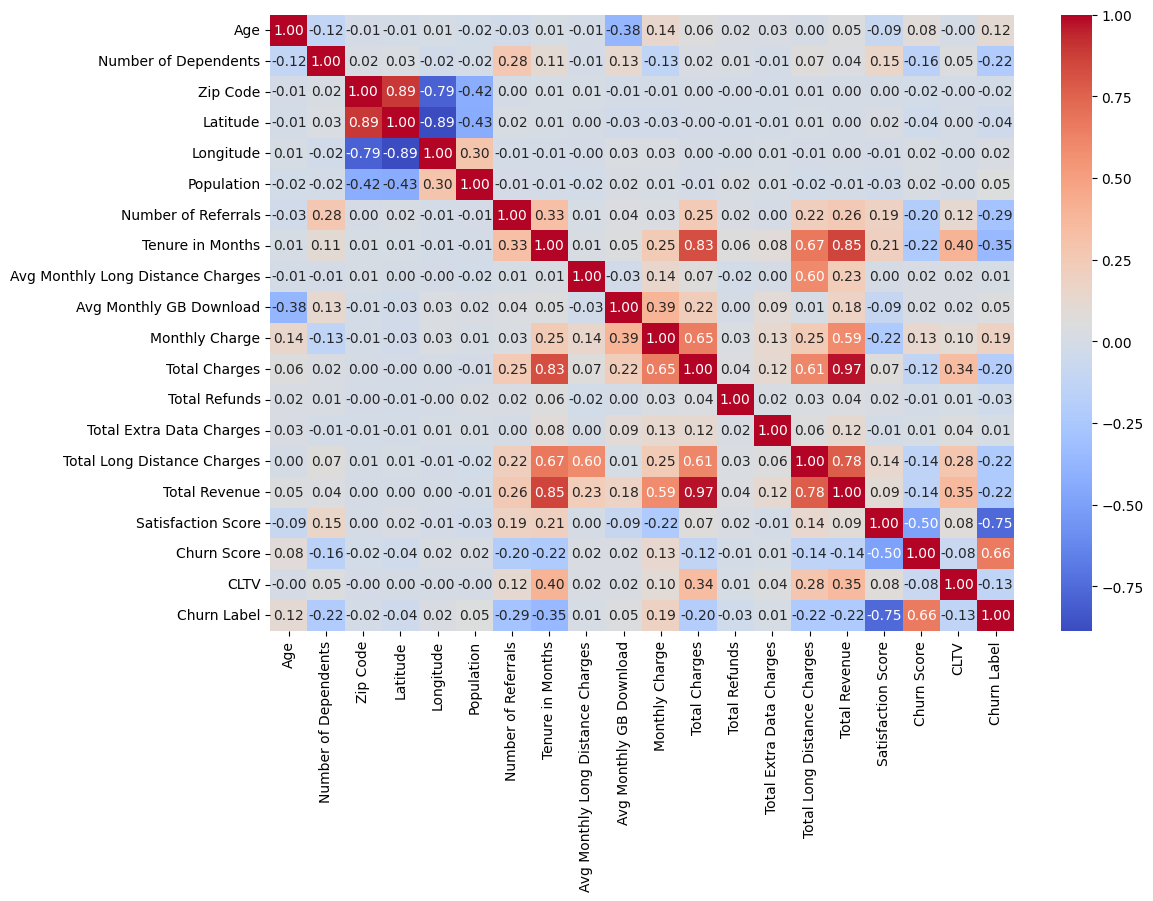

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(num_col.corr(),annot=True,fmt = '.2f',cmap='coolwarm')
plt.show()

In [39]:
cols = cat_col
alpha = 0.05
result = []

for col in cols:
    table = pd.crosstab(df1['Churn Label'],df1[col])
    chi2,dof,p_val,expected = chi2_contingency(table)
    decision = 'Keep Feature' if p_val < alpha else 'Reject Feature'

    result.append({
        'Feature': col,
        'chi2':chi2,
        'p_val':p_val,
        'decision':decision
    })


result = pd.DataFrame(result)
result.sort_values(by='p_val')

,Feature,chi2,p_val,decision
6,Country,0.000000,0,Keep Feature
7,State,0.000000,0,Keep Feature
9,Quarter,0.000000,0,Keep Feature
13,Multiple Lines,11.143251,1,Reject Feature
20,Streaming TV,27.862522,1,Reject Feature
19,Premium Tech Support,190.166842,1,Reject Feature
18,Device Protection Plan,30.513395,1,Reject Feature
17,Online Backup,47.260854,1,Reject Feature
16,Online Security,205.633104,1,Reject Feature
23,Unlimited Data,194.549217,1,Reject Feature


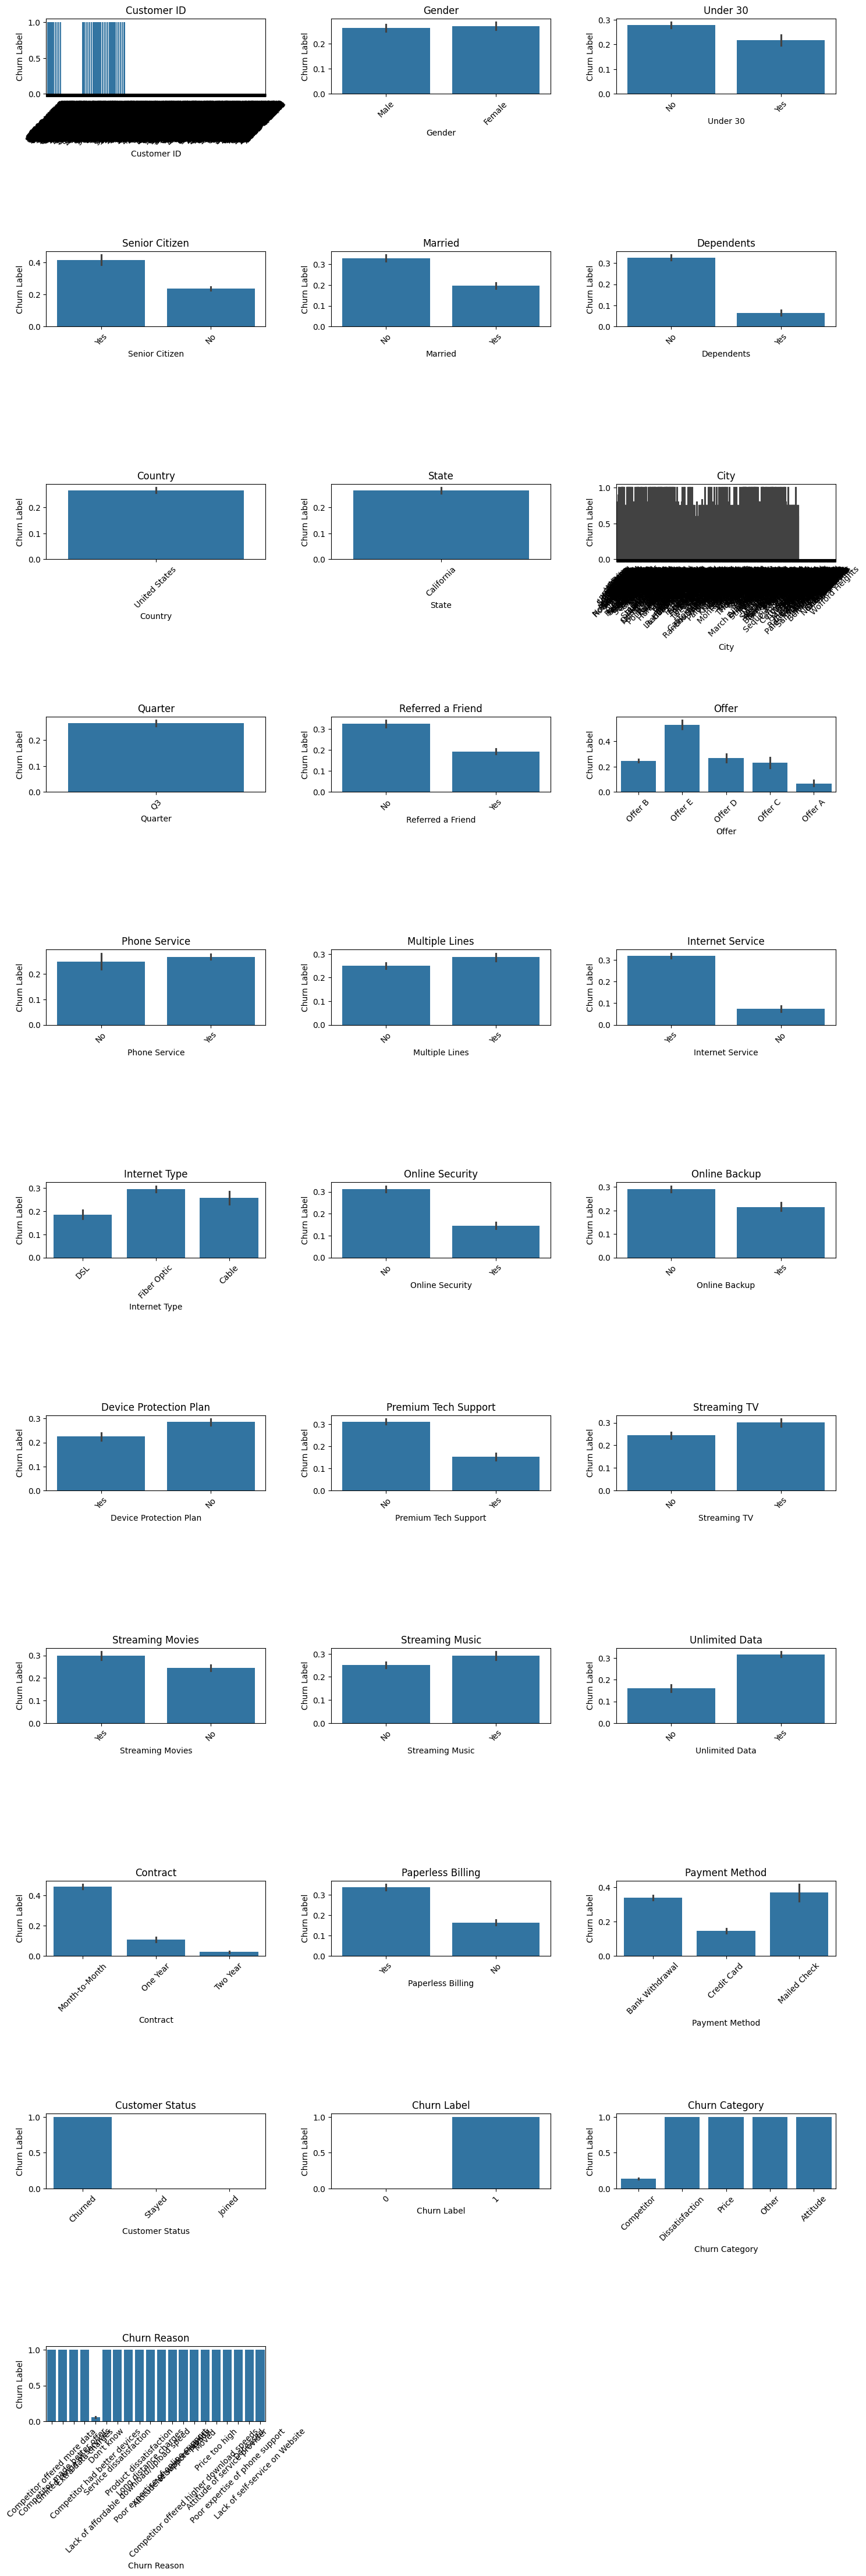

In [40]:
cat_cols = ['Gender', 'Under 30', 'Senior Citizen', 'Married','Dependents', 'City','Referred a Friend', 
            'Offer', 'Phone Service', 'Multiple Lines','Internet Service', 'Internet Type', 'Online Security',
              'Online Backup','Device Protection Plan', 'Premium Tech Support', 'Streaming TV','Streaming Movies', 
              'Streaming Music', 'Unlimited Data', 'Contract','Paperless Billing', 'Payment Method','Customer Status', 
              'Churn Label','Churn Category', 'Churn Reason']


n = len(cat_col)
rows = (n//3)+1

plt.figure(figsize=(15, rows*4))
for i,col in enumerate(cat_col,1):
    
    plt.subplot(rows,3,i)
    sns.barplot(x=col,y='Churn Label', data = df1)
    plt.title(col)
    plt.xticks(rotation = 45)

plt.tight_layout() 
plt.show()

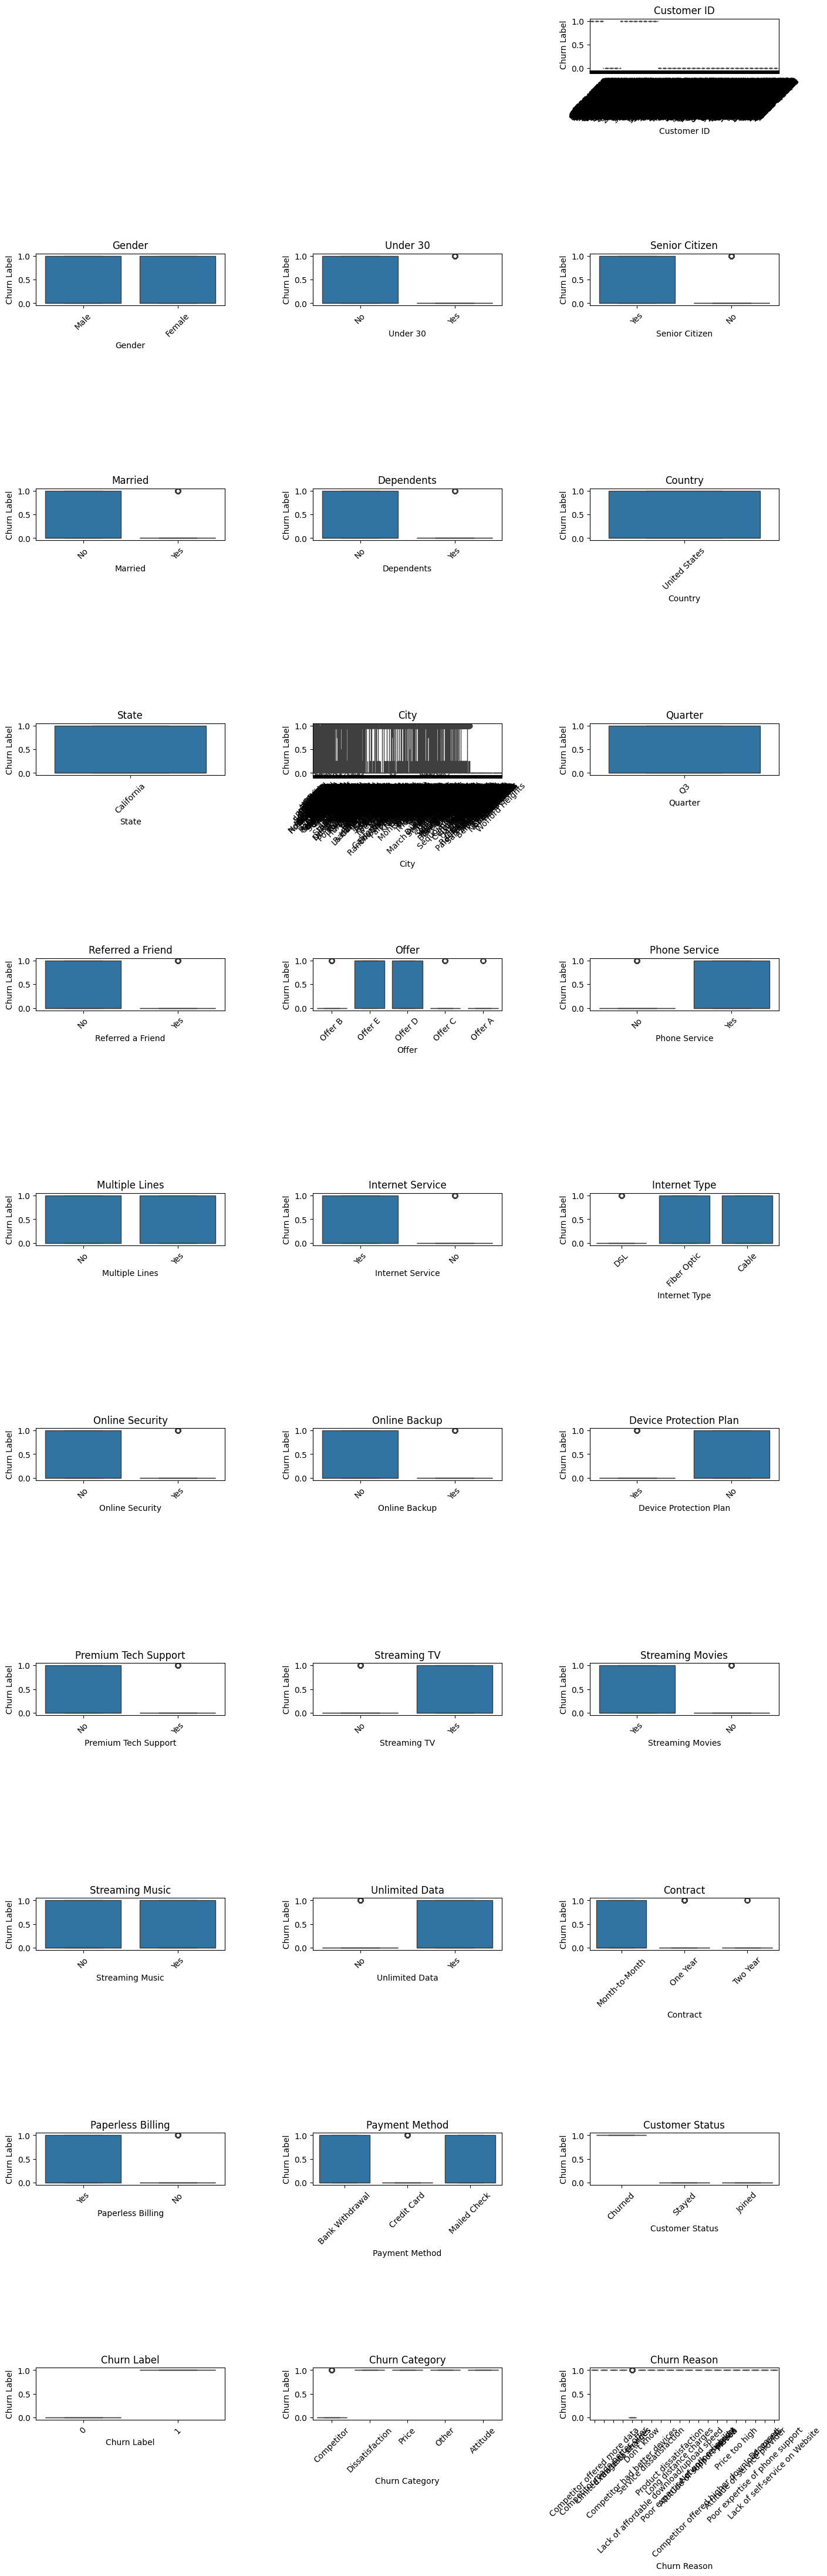

In [42]:
cat_cols = ['Gender', 'Under 30', 'Senior Citizen', 'Married','Dependents', 'City','Referred a Friend', 
            'Offer', 'Phone Service', 'Multiple Lines','Internet Service', 'Internet Type', 'Online Security',
              'Online Backup','Device Protection Plan', 'Premium Tech Support', 'Streaming TV','Streaming Movies', 
              'Streaming Music', 'Unlimited Data', 'Contract','Paperless Billing', 'Payment Method','Customer Status', 
              'Churn Label','Churn Category', 'Churn Reason']


n= len(cat_col)
rows = (n//3)+1

plt.figure(figsize=(15,rows*4))
for i ,col in enumerate(cat_col,i):
    
    plt.subplot(rows,3,i)
    sns.boxplot(x=col,y='Churn Label',data=df1)
    plt.title(col)
    plt.xticks(rotation = 45)
    

plt.tight_layout(pad=4.0)
plt.show()



In [43]:
df1.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [44]:
df1 = df1.drop(columns=['Customer ID', 'Gender','Country', 'State','City','Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter','Total Refunds','Total Revenue', 'CLTV','Satisfaction Score','Customer Status','Churn Score','Churn Category', 'Churn Reason'])

In [45]:
df1.columns

Index(['Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Churn Label'],
      dtype='object')

In [46]:
df1.shape

(7043, 32)

In [47]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Under 30                           7043 non-null   object 
 2   Senior Citizen                     7043 non-null   object 
 3   Married                            7043 non-null   object 
 4   Dependents                         7043 non-null   object 
 5   Number of Dependents               7043 non-null   int64  
 6   Referred a Friend                  7043 non-null   object 
 7   Number of Referrals                7043 non-null   int64  
 8   Tenure in Months                   7043 non-null   int64  
 9   Offer                              7043 non-null   object 
 10  Phone Service                      7043 non-null   object 
 11  Avg Monthly Long Distance Charges  7043 non-null   float

In [48]:
df1.isnull().sum()

Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                             0
Paperless Billing        

In [49]:
print(df1.isnull().sum()[df1.isnull().sum()>0])

Series([], dtype: int64)


C:\Users\bhask\AppData\Local\Temp\ipykernel_15112\505368310.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,5))


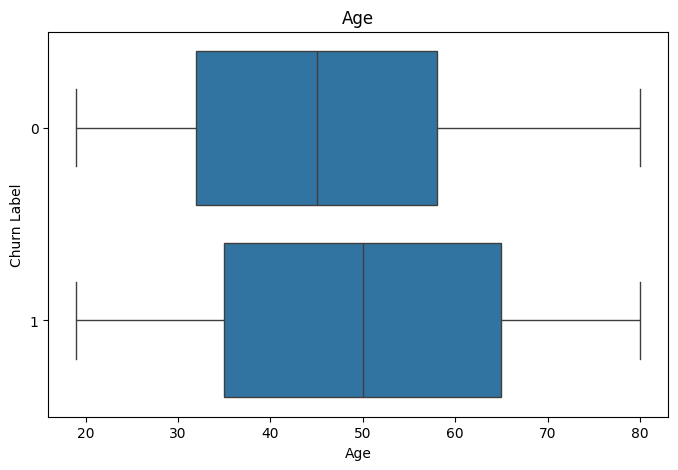

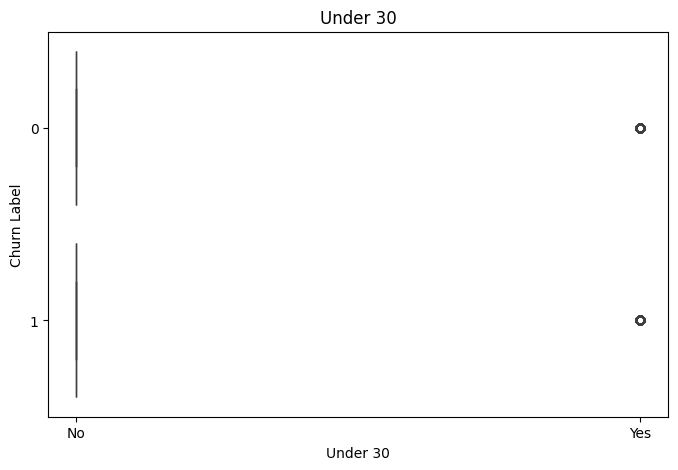

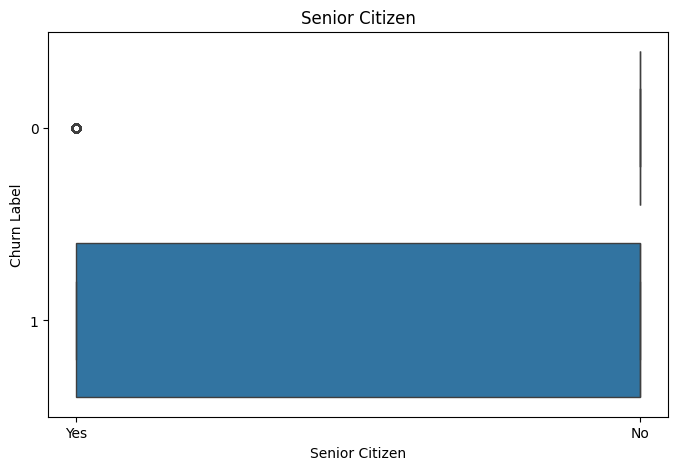

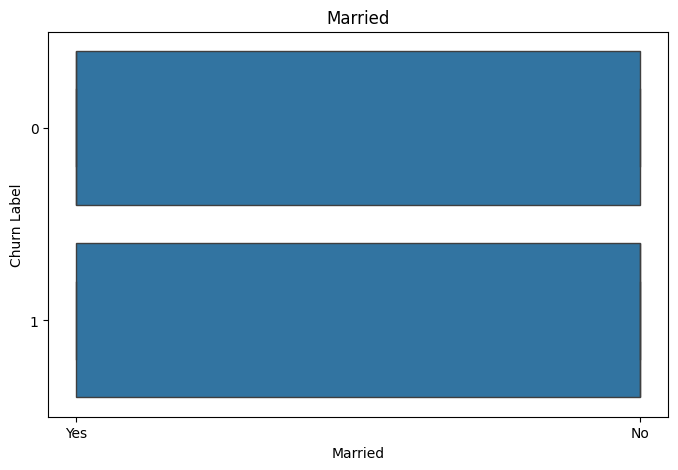

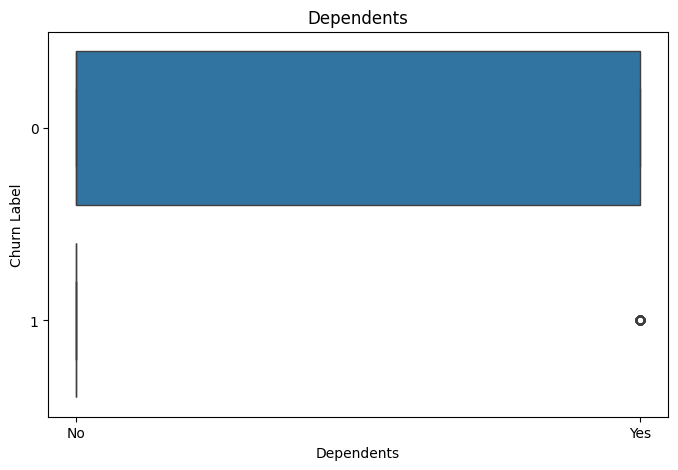

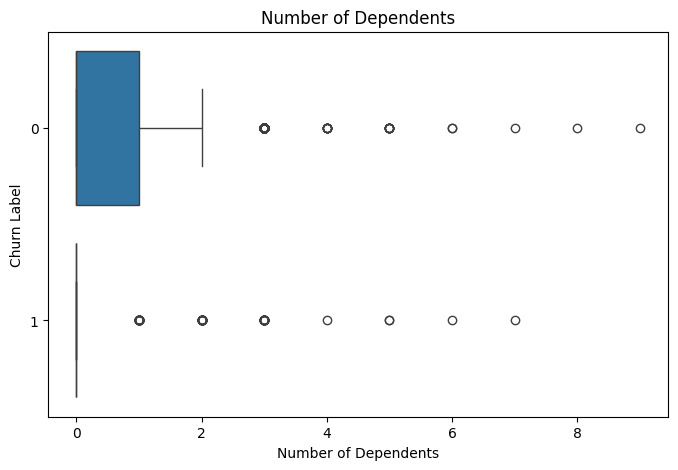

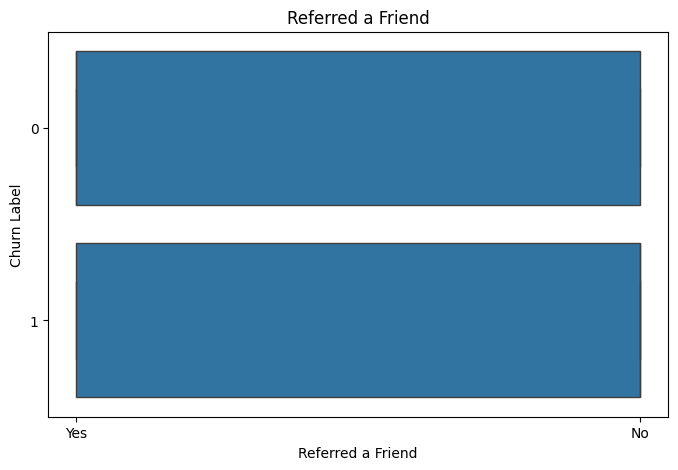

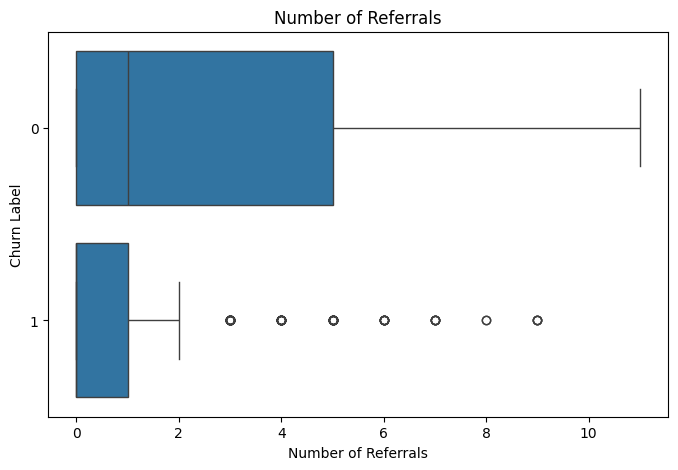

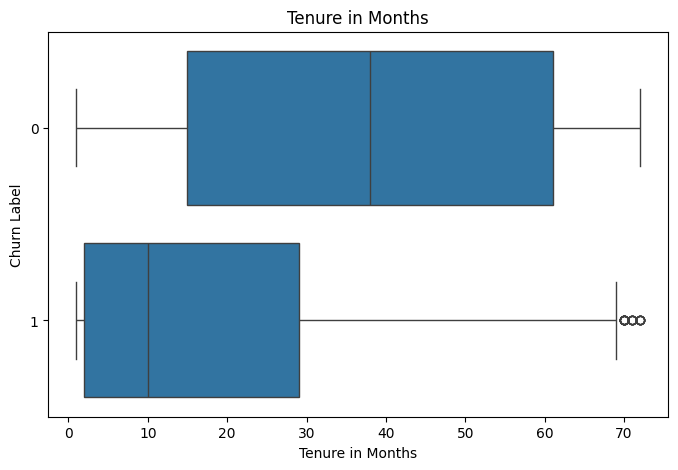

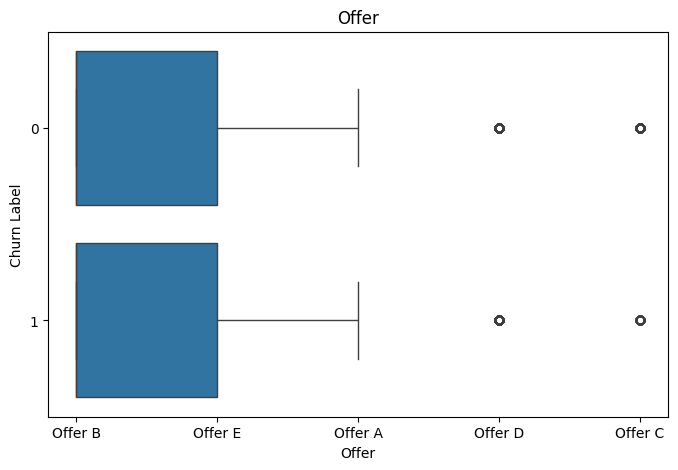

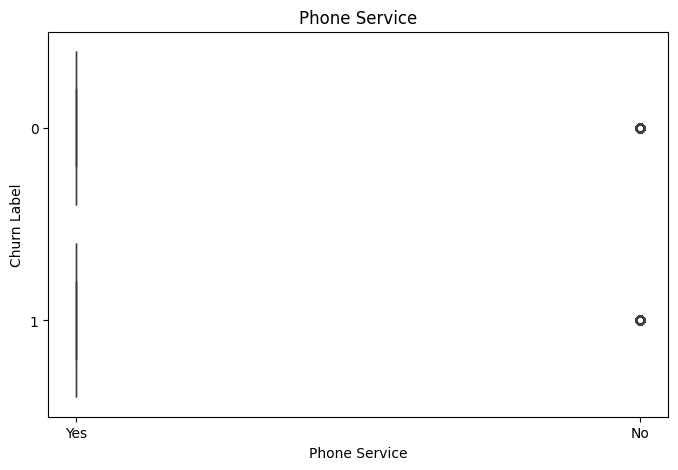

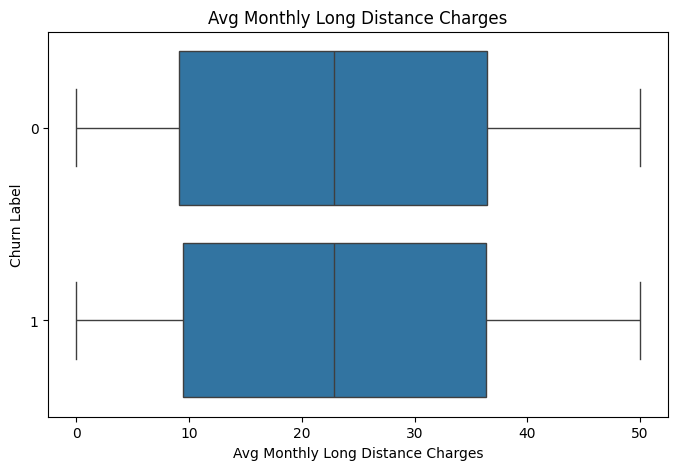

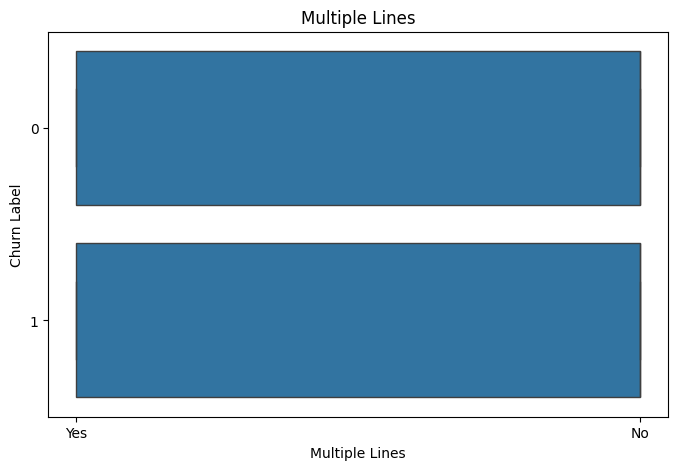

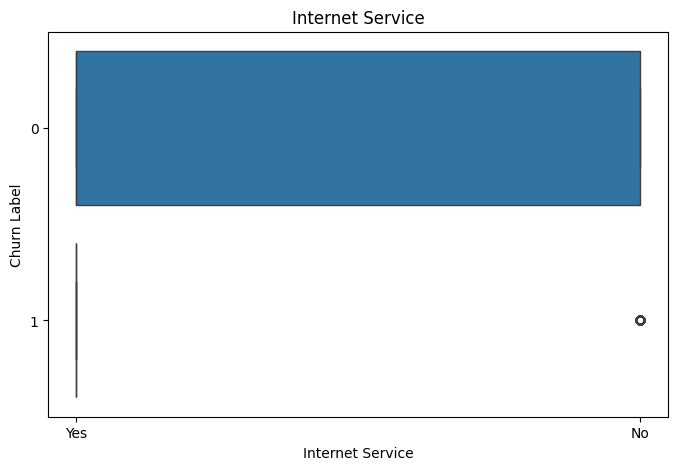

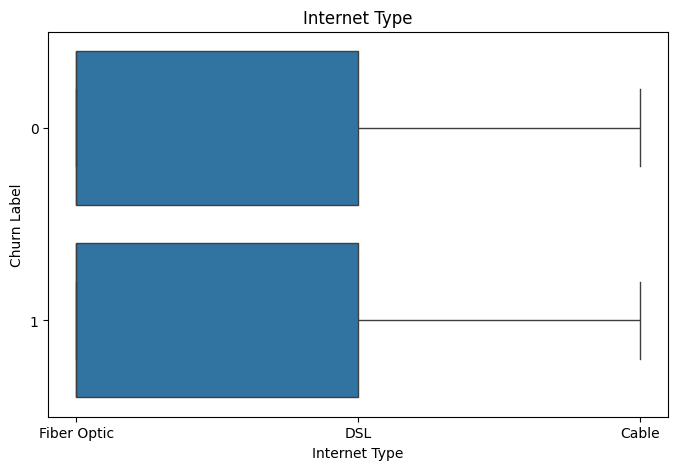

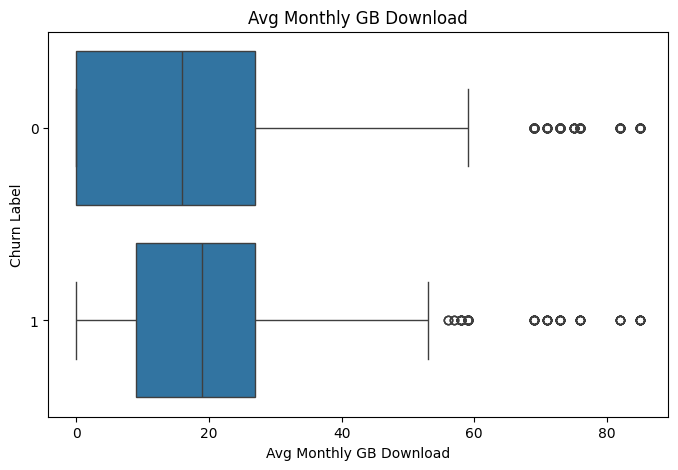

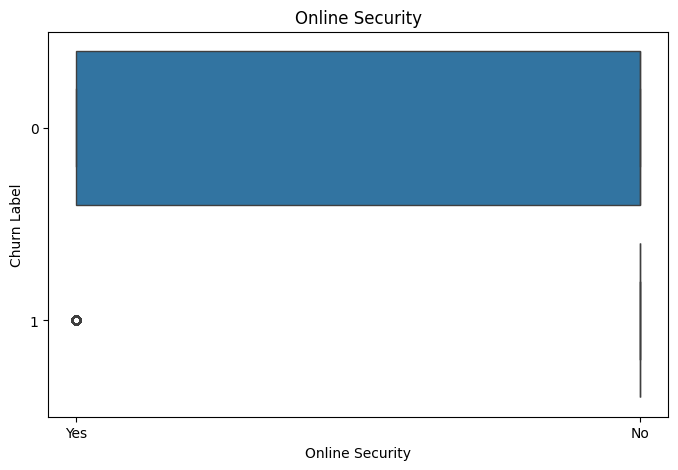

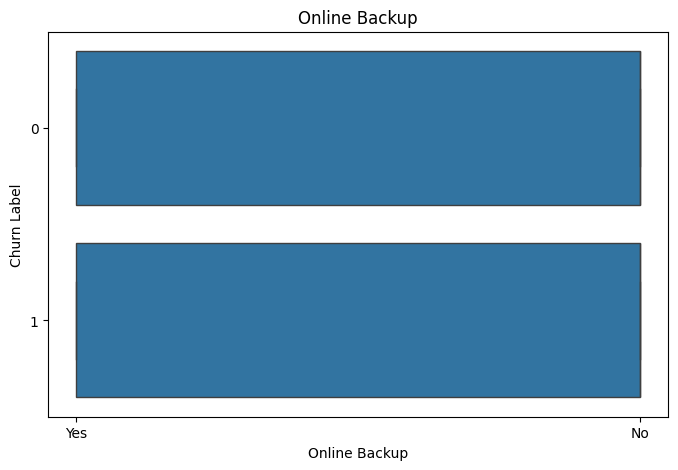

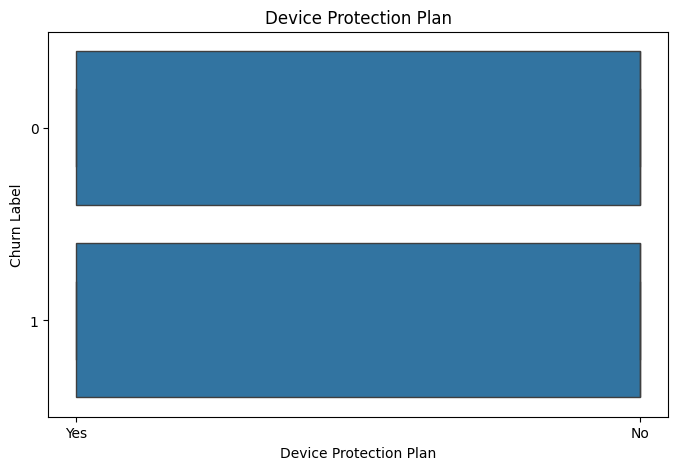

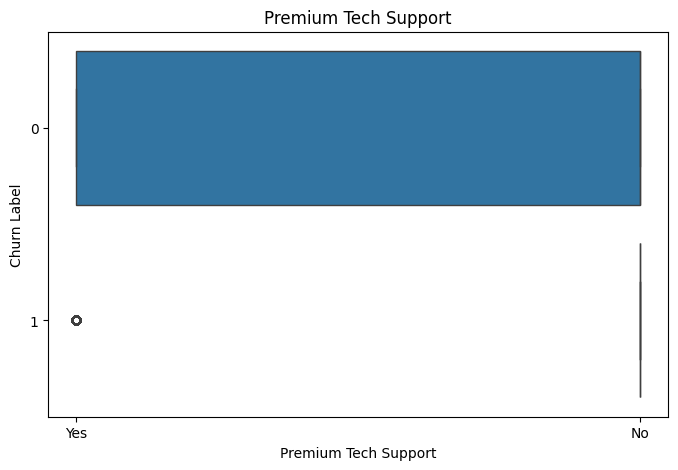

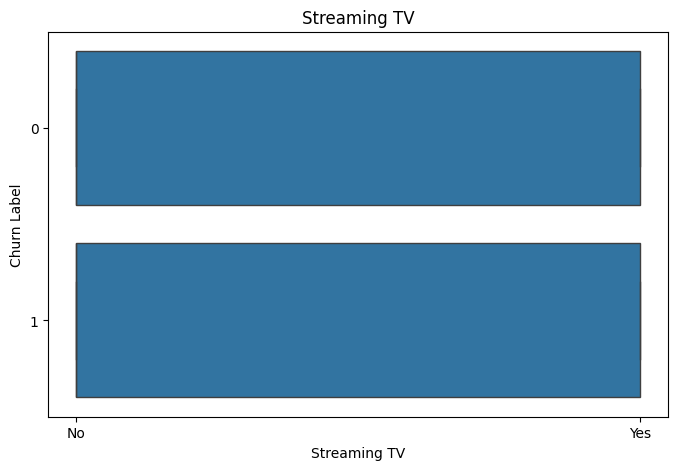

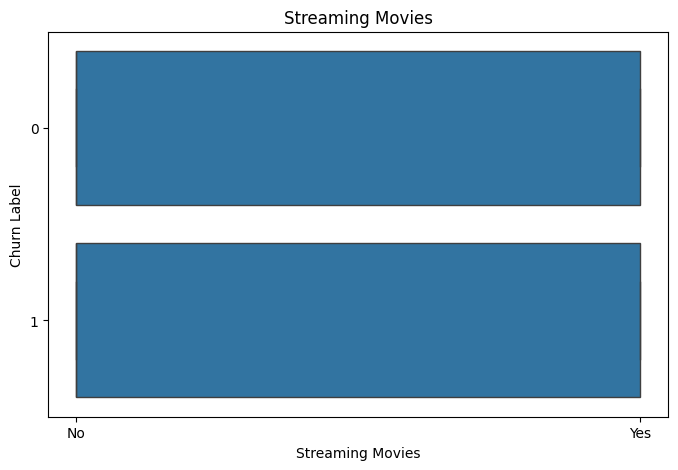

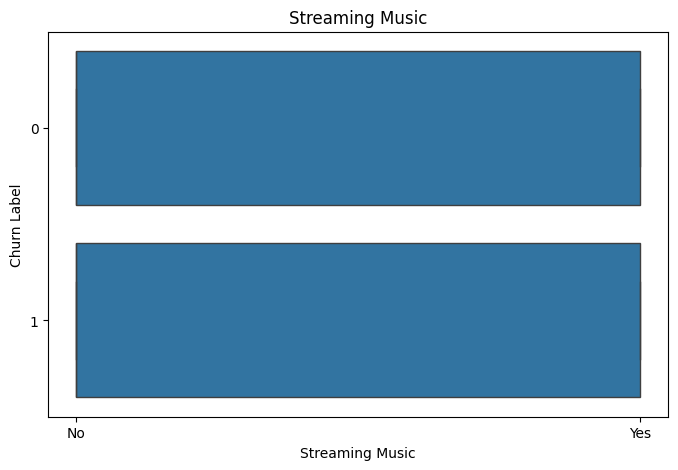

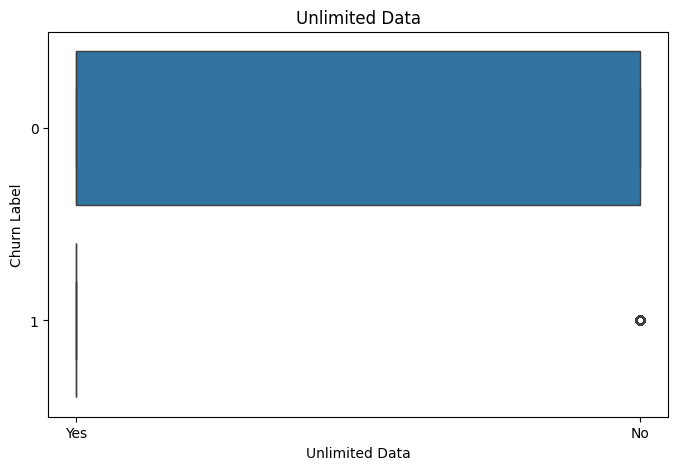

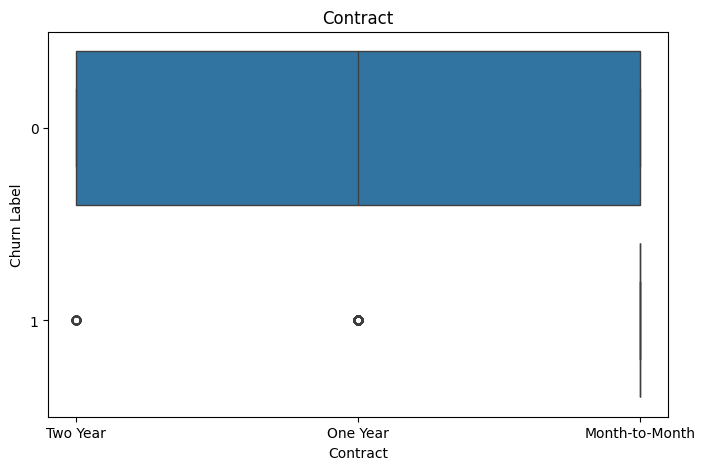

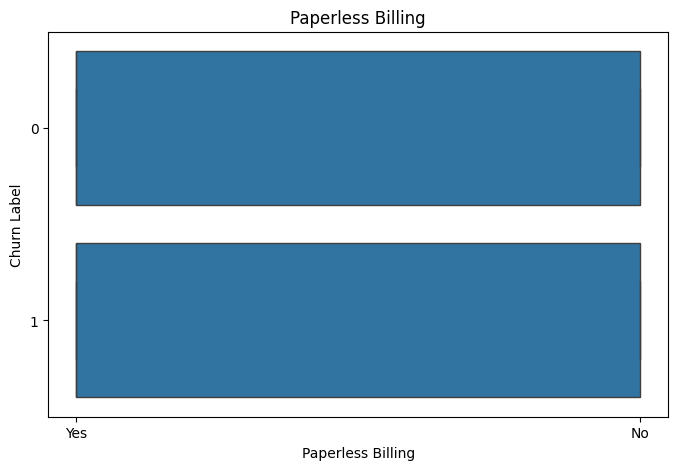

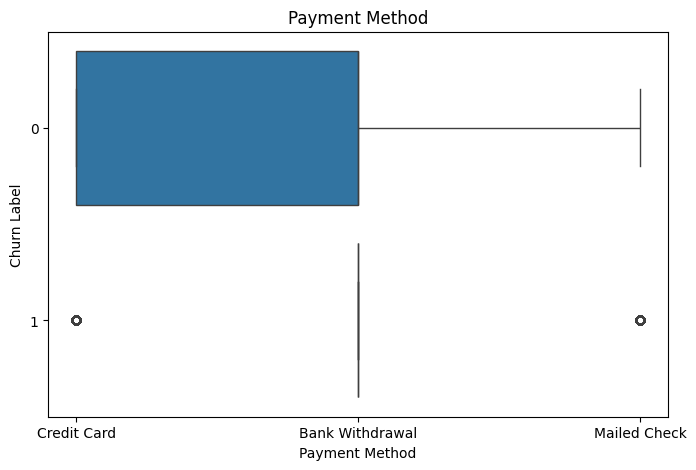

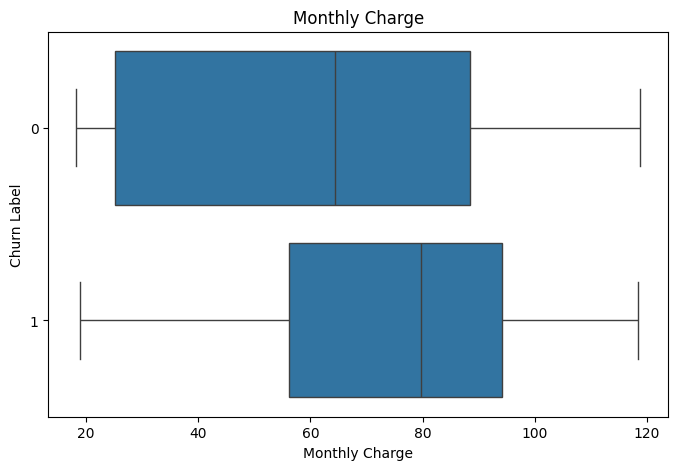

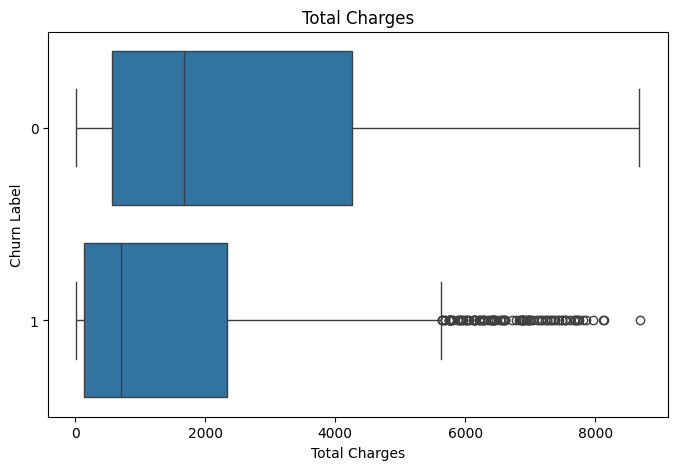

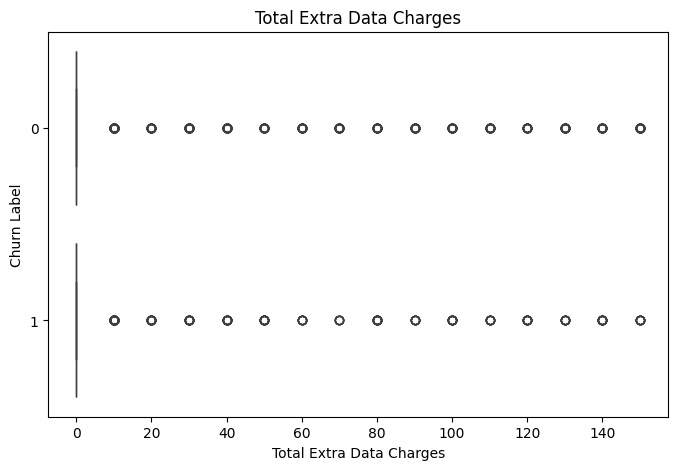

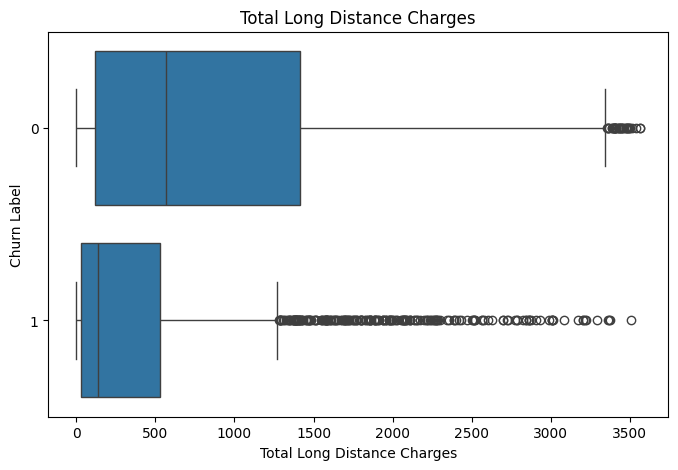

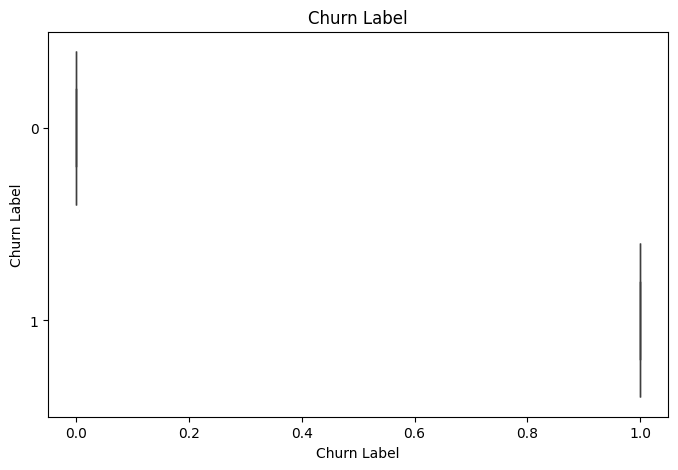

In [50]:
cols = ['Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Churn Label']

for col in cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=col,y='Churn Label',data= df1,orient='h')
    plt.title(col)
plt.show()

In [51]:
cols = ['Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Churn Label']


In [52]:
for col in df1.select_dtypes(include='number').columns:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower = Q1-(1.5*IQR)
    upper = Q3+(1.5*IQR)

    outliers = df1[(df1[col]<lower)| (df1[col]>upper)]
    print (f"{col}:{len(outliers)} outliers")


Age:0 outliers
Number of Dependents:1627 outliers
Number of Referrals:676 outliers
Tenure in Months:0 outliers
Avg Monthly Long Distance Charges:0 outliers
Avg Monthly GB Download:362 outliers
Monthly Charge:0 outliers
Total Charges:0 outliers
Total Extra Data Charges:728 outliers
Total Long Distance Charges:196 outliers
Churn Label:0 outliers


In [53]:
for col in df1.select_dtypes(include='number').columns:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower = Q1-(1.5*IQR)
    upper = Q3+(1.5*IQR)

    outliers = df1[(df1[col]<lower)| (df1[col]>upper)]
    pct = len(outliers)/len(df1)*100
    print (f"{col}:{len(outliers)} outliers ({pct:.2f}%)")


Age:0 outliers (0.00%)
Number of Dependents:1627 outliers (23.10%)
Number of Referrals:676 outliers (9.60%)
Tenure in Months:0 outliers (0.00%)
Avg Monthly Long Distance Charges:0 outliers (0.00%)
Avg Monthly GB Download:362 outliers (5.14%)
Monthly Charge:0 outliers (0.00%)
Total Charges:0 outliers (0.00%)
Total Extra Data Charges:728 outliers (10.34%)
Total Long Distance Charges:196 outliers (2.78%)
Churn Label:0 outliers (0.00%)


In [54]:
Q1 = df1['Total Long Distance Charges'].quantile(0.25)
Q3 = df1['Total Long Distance Charges'].quantile(0.75)
    
IQR = Q3 - Q1

lower = Q1-(1.5*IQR)
upper = Q3+(1.5*IQR)

df1['Total Long Distance Charges'] = df1['Total Long Distance Charges'].clip(lower,upper)

In [55]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [56]:
df1['Churn Label']

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, Length: 7043, dtype: int64

In [57]:
y = df1['Churn Label'] 

In [58]:
cat_col = df1.select_dtypes(include='object')

In [59]:
print(cat_col)

     Under 30 Senior Citizen Married Dependents Referred a Friend    Offer  \
0          No            Yes      No         No                No  Offer B   
1          No            Yes     Yes        Yes               Yes  Offer E   
2          No            Yes      No        Yes                No  Offer D   
3          No            Yes     Yes        Yes               Yes  Offer C   
4          No            Yes     Yes        Yes               Yes  Offer C   
...       ...            ...     ...        ...               ...      ...   
7038       No             No      No         No                No  Offer B   
7039       No             No     Yes        Yes               Yes  Offer C   
7040       No             No     Yes        Yes               Yes  Offer B   
7041       No             No     Yes        Yes               Yes  Offer B   
7042       No             No      No         No                No  Offer B   

     Phone Service Multiple Lines Internet Service Internet Typ

In [60]:
cat_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Under 30                7043 non-null   object
 1   Senior Citizen          7043 non-null   object
 2   Married                 7043 non-null   object
 3   Dependents              7043 non-null   object
 4   Referred a Friend       7043 non-null   object
 5   Offer                   7043 non-null   object
 6   Phone Service           7043 non-null   object
 7   Multiple Lines          7043 non-null   object
 8   Internet Service        7043 non-null   object
 9   Internet Type           7043 non-null   object
 10  Online Security         7043 non-null   object
 11  Online Backup           7043 non-null   object
 12  Device Protection Plan  7043 non-null   object
 13  Premium Tech Support    7043 non-null   object
 14  Streaming TV            7043 non-null   object
 15  Stre

In [61]:
df1.columns

Index(['Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Churn Label'],
      dtype='object')

In [62]:
encoders = {}

cat_cols = df1.select_dtypes(include='object')
for col in cat_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])
    encoders[col] = le

In [63]:
df1.columns

Index(['Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Churn Label'],
      dtype='object')

In [64]:
df1= df1.drop(columns="Churn Label")

In [65]:
scaler = StandardScaler()
scaled_df1 = scaler.fit_transform(df1)

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score




In [67]:
X = scaled_df1 

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [69]:
models = {
    "LO": LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "NB":GaussianNB(),
    "svc":SVC(),
    "DT":DecisionTreeClassifier()
}

results = []

for names,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred,average='weighted')
    recall = recall_score(y_test,y_pred,average='weighted') 

    results.append({
        "model":names,
        "Acc":round(acc,2),
        "F1":round(f1,2),
        "Recall":round(recall,2)
    })


In [70]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='Acc',ascending=False)

,model,Acc,F1,Recall
0,LO,0.84,0.84,0.84
3,svc,0.84,0.83,0.84
1,KNN,0.80,0.80,0.80
2,NB,0.78,0.79,0.78
4,DT,0.78,0.78,0.78


In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier

In [72]:
Rf = RandomForestClassifier()
Rf.fit(X_train,y_train)
y_pred = Rf.predict(X_test)
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred,average="weighted")
recall = recall_score(y_test,y_pred , average="weighted")
print (acc,f1,recall)

0.8412903225806452 0.836075608147177 0.8412903225806452


In [73]:
base_learner = [
    (("LO"), (LogisticRegression())),
    (("KNN"),(KNeighborsClassifier()) ) ,
    (("svc") ,(SVC()))
]

meta_learner = RandomForestClassifier()

clf = StackingClassifier(estimators=base_learner,final_estimator=meta_learner)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred,average="weighted")
recall = recall_score(y_test,y_pred , average="weighted")
print (acc,f1,recall)


0.8253763440860215 0.8206045816163084 0.8253763440860215


In [74]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

In [75]:
model = LogisticRegression()
cv = cross_validate(estimator=model, X=X_train,y=y_train, cv=5)
print(cv)

{'fit_time': array([0.05715489, 0.05963206, 0.05328965, 0.0403688 , 0.04353714]), 'score_time': array([0.00384712, 0.00269532, 0.00307441, 0.00227571, 0.00212026]), 'test_score': array([0.84004237, 0.84004237, 0.83262712, 0.84093319, 0.84093319])}


In [76]:
parameters =  {
    "Cs":10, 
    "l1_ratios":'warn',
    "fit_intercept":True,  
    "solver":'lbfgs',
    "tol":0.0001,
    "max_iter":100
    }

GD_results = GridSearchCV(estimator=LogisticRegression(),param_grid=parameters,cv=5)
GD_results

,estimator,LogisticRegression()
,param_grid,"{'Cs': 10, 'fit_intercept': True, 'l1_ratios': 'warn', 'max_iter': 100, ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [77]:
parameters = {
    "C": [0.1, 1, 10],
    "solver": ['lbfgs', 'liblinear'],
    "max_iter": [100, 200],
    "fit_intercept": [True, False]
}

GD_results = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=parameters,
    cv=5,
    scoring='accuracy'
)

GD_results.fit(X_train, y_train)

print("Best Parameters:", GD_results.best_params_)
print("Best Score:", round(GD_results.best_score_, 2))

Best Parameters: {'C': 10, 'fit_intercept': True, 'max_iter': 100, 'solver': 'liblinear'}
Best Score: 0.84
